# CS6421 Assignment 2: Autoencoders

This assignment will focus on designing denoising autoencoders.

<a target="_blank" href="https://colab.research.google.com/github/andrew-nash/CS6421-labs-2025/blob/main/CS6421_Assignment_02.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

Due on  20/03/2025 at 23:59:59 UTC

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

## Task 1: Implementing A CNN-Based Denoising Auto-encoder

For task 1, we will fit a denoising autoencoder to the MNIST data.

We will train the autoencoder by fitting noisy inputs against clean outputs. We will manually add the noise to the inoputs

### Data

In [ ]:
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

np.random.seed(42)
x_train_noisy = x_train + np.random.normal(loc=0.0, scale=0.75, size=x_train.shape)
x_test_noisy = x_test + np.random.normal(loc=0.0, scale=0.75, size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


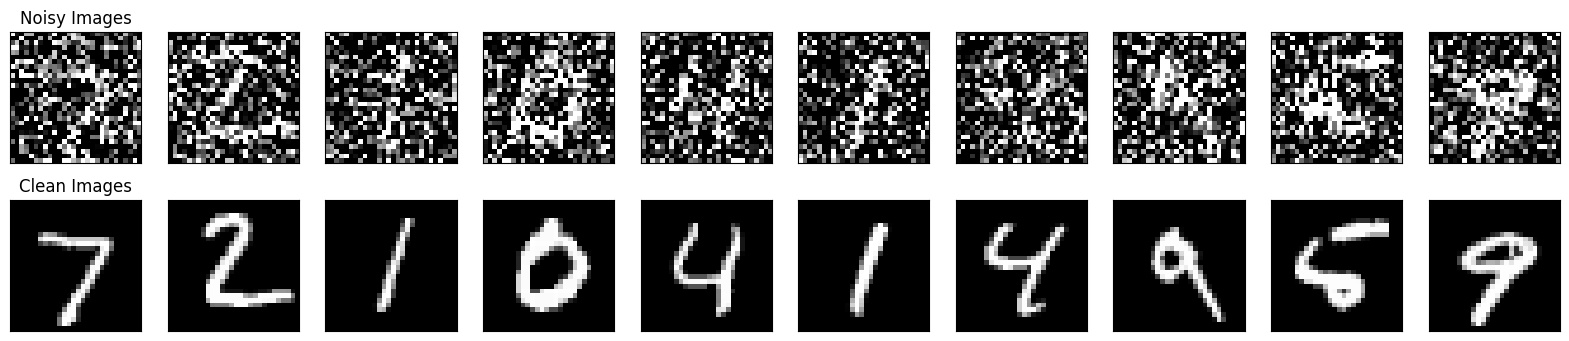

In [ ]:
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
      ax.set_title('Noisy Images')
for i in range(n):
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title('Clean Images')

plt.show()


In [50]:
class AutoEncoder(tf.keras.models.Model):
  def __init__(self):
    super(AutoEncoder, self).__init__()
    self.encoder = tf.keras.Sequential([
      tf.keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
      tf.keras.layers.MaxPooling2D((2, 2), padding='same'),
      tf.keras.layers.Conv2D(8, (2, 2), activation='relu', padding='same'),
      tf.keras.layers.MaxPooling2D((2, 2), padding='same'),
    ])

    self.decoder = tf.keras.Sequential([
      tf.keras.layers.Conv2DTranspose(8,(3,3),strides=(2,2),activation='relu',padding='same'),
      tf.keras.layers.Conv2DTranspose(8,(3,3),strides=(2,2),activation='relu',padding='same'),
       tf.keras.layers.Conv2D(1,(3,3),strides=(1,1),activation='relu',padding='same'),
      ])

  def call(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded

autoencoder = AutoEncoder()

autoencoder.compile(optimizer='adam', loss='mse')



tensorboard_callback = tf.keras.callbacks.TensorBoard(f"./tboard/dense_basic", histogram_freq=1)
autoencoder.fit(x_train_noisy, x_train,
          epochs=10,
          batch_size=512,
          validation_split=0.8,
          shuffle=True, callbacks=[tensorboard_callback])

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 779ms/step - loss: 0.0944 - val_loss: 0.0823
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 801ms/step - loss: 0.0800 - val_loss: 0.0682
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - loss: 0.0633 - val_loss: 0.0510
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - loss: 0.0497 - val_loss: 0.0474
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - loss: 0.0465 - val_loss: 0.0451
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - loss: 0.0441 - val_loss: 0.0429
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - loss: 0.0421 - val_loss: 0.0412
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - loss: 0.0404 - val_loss: 0.0400
Epoch 9/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - loss: 0.0393 - val_loss: 0.0391
Epoch 10/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - loss: 0.0384 - val_loss: 0.0383


When defining a CNN-based autoencoder, you have to pay carfeul attention to the `strides`, to make sure that the input and output dimensions are the same.

The last layer can be a Conv2D or a Conv2DTranspose - so long as it only has a single filter, to correspond to the single channel in the input image.

In [ ]:
autoencoder.encoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 8)           │             520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 8)             │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 680 (2.66 KB)

 Trainable params: 680 (2.66 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
autoencoder.decoder.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_transpose (Conv2DTranspose)   │ (None, 14, 14, 8)           │             584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_1 (Conv2DTranspose) │ (None, 28, 28, 8)           │             584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 1)           │              73 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,241 (4.85 KB)

 Trainable params: 1,241 (4.85 KB)

 Non-trainable params: 0 (0.00 B)

#### Visualizations

Compare, original, noisy and reconstructed outputs:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


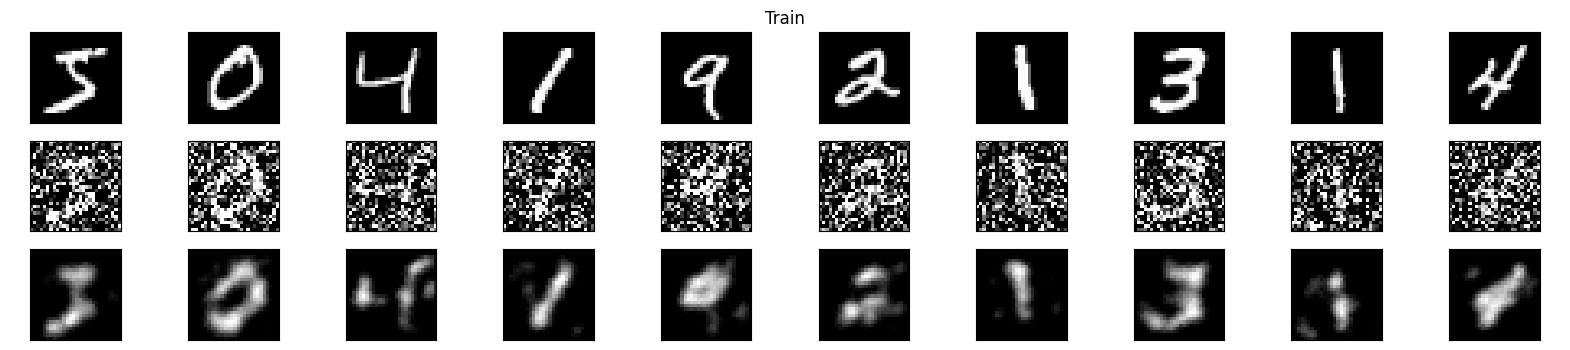

In [62]:
n = 10
decoded_imgs = autoencoder.predict(x_train_noisy[:n])

plt.figure(figsize=(20, 4))
plt.title("Train")
plt.axis('off')
for i in range(10):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_train[i].reshape(28, 28))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_train_noisy[i].reshape(28, 28))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


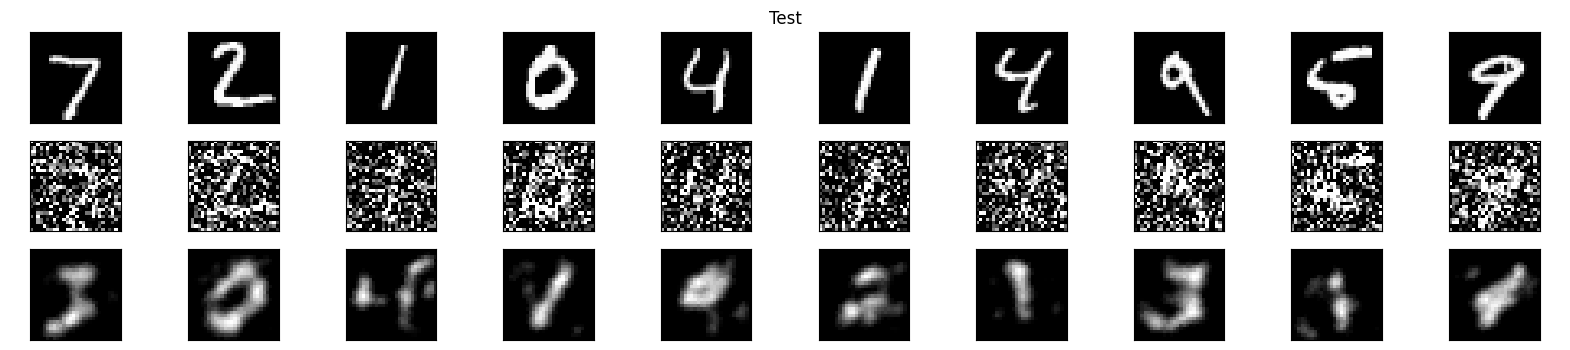

In [64]:
n = 10
decoded_imgs = autoencoder.predict(x_train_noisy[:n])

plt.figure(figsize=(20, 4))
plt.title("Test")
plt.axis('off')
for i in range(10):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)









### Exercise 1




1. Adjust the autoencoder to have **at least 2** other different bottleneck sizes, one larger and one smaller than the given dimensions. In the given example above, this dimension is (None, 4, 4, 8)->4x4x8=128.

2. You may (and should) spend a little time tuning the model hyper-parameters to try to achieve good results on each.

3. Visualize the results of applying each model to some samples from the train and test sets.

4. Write a brief discussion of your results comparing the performance of each model, with justufiction as to **why** you think these results occurred

In [ ]:
### CODE ....

In [55]:
# Smaller bottleneck

class AutoEncoderSmall(tf.keras.models.Model):
    def __init__(self):
        super(AutoEncoderSmall, self).__init__()
        # We reduce filters and/or add an extra pooling to shrink the latent space
        self.encoder = tf.keras.Sequential([
            tf.keras.layers.Conv2D(8, (3,3), activation='relu', padding='same'),
            tf.keras.layers.MaxPooling2D((2,2), padding='same'),
            tf.keras.layers.Conv2D(4, (3,3), activation='relu', padding='same'),
            tf.keras.layers.MaxPooling2D((2,2), padding='same'),
            # Optionally add another pooling to shrink further, but be mindful
            # of reconstruction difficulty if the dimension is too small.
        ])
        self.decoder = tf.keras.Sequential([
            tf.keras.layers.Conv2DTranspose(4, (3,3), strides=(2,2), activation='relu', padding='same'),
            tf.keras.layers.Conv2DTranspose(4, (3,3), strides=(2,2), activation='relu', padding='same'),
            tf.keras.layers.Conv2D(1, (3,3), activation='sigmoid', padding='same')
        ])

    def call(self, x):
      encoded = self.encoder(x)
      decoded = self.decoder(encoded)
      return decoded



In [54]:
# larger bottleneck

class AutoEncoderLarge(tf.keras.models.Model):
    def __init__(self):
        super(AutoEncoderLarge, self).__init__()
        # Increase number of filters (and/or reduce pooling) to inflate the latent dimension
        self.encoder = tf.keras.Sequential([
            tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'),
            tf.keras.layers.MaxPooling2D((2,2), padding='same'),
            tf.keras.layers.Conv2D(16, (3,3), activation='relu', padding='same'),
            tf.keras.layers.MaxPooling2D((2,2), padding='same'),
            # Could remove or modify a pooling layer to further enlarge the bottleneck
        ])
        self.decoder = tf.keras.Sequential([
            tf.keras.layers.Conv2DTranspose(16, (3,3), strides=(2,2), activation='relu', padding='same'),
            tf.keras.layers.Conv2DTranspose(16, (3,3), strides=(2,2), activation='relu', padding='same'), # changed to 16 from 32
            tf.keras.layers.Conv2D(1, (3,3), activation='sigmoid', padding='same')
        ])

    def call(self, x):
      encoded = self.encoder(x)
      decoded = self.decoder(encoded)
      return decoded
"""
class AutoEncoder(tf.keras.models.Model):
  def __init__(self):
    super(AutoEncoder, self).__init__()
    self.encoder = tf.keras.Sequential([
      tf.keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
      tf.keras.layers.MaxPooling2D((2, 2), padding='same'),
      tf.keras.layers.Conv2D(8, (2, 2), activation='relu', padding='same'),
      tf.keras.layers.MaxPooling2D((2, 2), padding='same'),
    ])

    self.decoder = tf.keras.Sequential([
      tf.keras.layers.Conv2DTranspose(8,(3,3),strides=(2,2),activation='relu',padding='same'),
      tf.keras.layers.Conv2DTranspose(8,(3,3),strides=(2,2),activation='relu',padding='same'),
       tf.keras.layers.Conv2D(1,(3,3),strides=(1,1),activation='relu',padding='same'),
      ])

  def call(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded

autoencoder = AutoEncoder()

autoencoder.compile(optimizer='adam', loss='mse')



tensorboard_callback = tf.keras.callbacks.TensorBoard(f"./tboard/dense_basic", histogram_freq=1)
autoencoder.fit(x_train_noisy, x_train,
          epochs=10,
          batch_size=512,
          validation_split=0.8,
          shuffle=True, callbacks=[tensorboard_callback])

"""



'\nclass AutoEncoder(tf.keras.models.Model):\n  def __init__(self):\n    super(AutoEncoder, self).__init__()\n    self.encoder = tf.keras.Sequential([\n      tf.keras.layers.Conv2D(16, (3, 3), activation=\'relu\', padding=\'same\'),\n      tf.keras.layers.MaxPooling2D((2, 2), padding=\'same\'),\n      tf.keras.layers.Conv2D(8, (2, 2), activation=\'relu\', padding=\'same\'),\n      tf.keras.layers.MaxPooling2D((2, 2), padding=\'same\'),\n    ])\n\n    self.decoder = tf.keras.Sequential([\n      tf.keras.layers.Conv2DTranspose(8,(3,3),strides=(2,2),activation=\'relu\',padding=\'same\'),\n      tf.keras.layers.Conv2DTranspose(8,(3,3),strides=(2,2),activation=\'relu\',padding=\'same\'),\n       tf.keras.layers.Conv2D(1,(3,3),strides=(1,1),activation=\'relu\',padding=\'same\'),\n      ])\n\n  def call(self, x):\n    encoded = self.encoder(x)\n    decoded = self.decoder(encoded)\n    return decoded\n\nautoencoder = AutoEncoder()\n\nautoencoder.compile(optimizer=\'adam\', loss=\'mse\')\n\n\n\

In [56]:
# initialisation

autoencoder_small    = AutoEncoderSmall()
autoencoder_large    = AutoEncoderLarge()

autoencoder_small.compile(optimizer='adam', loss='mse')
autoencoder_large.compile(optimizer='adam', loss='mse')

In [67]:
autoencoder.encoder.summary()
autoencoder.decoder.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)                   │ (None, 28, 28, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_20 (MaxPooling2D)      │ (None, 14, 14, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_31 (Conv2D)                   │ (None, 14, 14, 8)           │             520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_21 (MaxPooling2D)      │ (None, 7, 7, 8)             │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 680 (2.66 KB)

 Trainable params: 680 (2.66 KB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_transpose_20                  │ (None, 14, 14, 8)           │             584 │
│ (Conv2DTranspose)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_21                  │ (None, 28, 28, 8)           │             584 │
│ (Conv2DTranspose)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_32 (Conv2D)                   │ (None, 28, 28, 1)           │              73 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,241 (4.85 KB)

 Trainable params: 1,241 (4.85 KB)

 Non-trainable params: 0 (0.00 B)

In [68]:
autoencoder_small.encoder.summary()
autoencoder_small.decoder.summary()

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_33 (Conv2D)                   │ (None, 28, 28, 8)           │              80 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_22 (MaxPooling2D)      │ (None, 14, 14, 8)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_34 (Conv2D)                   │ (None, 14, 14, 4)           │             292 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_23 (MaxPooling2D)      │ (None, 7, 7, 4)             │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 372 (1.45 KB)

 Trainable params: 372 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_transpose_22                  │ (None, 14, 14, 4)           │             148 │
│ (Conv2DTranspose)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_23                  │ (None, 28, 28, 4)           │             148 │
│ (Conv2DTranspose)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_35 (Conv2D)                   │ (None, 28, 28, 1)           │              37 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 333 (1.30 KB)

 Trainable params: 333 (1.30 KB)

 Non-trainable params: 0 (0.00 B)

In [69]:
autoencoder_large.encoder.summary()
autoencoder_large.decoder.summary()

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_36 (Conv2D)                   │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_24 (MaxPooling2D)      │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_37 (Conv2D)                   │ (None, 14, 14, 16)          │           4,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_25 (MaxPooling2D)      │ (None, 7, 7, 16)            │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,944 (19.31 KB)

 Trainable params: 4,944 (19.31 KB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_transpose_24                  │ (None, 14, 14, 16)          │           2,320 │
│ (Conv2DTranspose)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_25                  │ (None, 28, 28, 16)          │           2,320 │
│ (Conv2DTranspose)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_38 (Conv2D)                   │ (None, 28, 28, 1)           │             145 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,785 (18.69 KB)

 Trainable params: 4,785 (18.69 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
# training - 1


EPOCHS = 10
BATCH_SIZE = 512
VALIDATION_SPLIT=0.8


print("Training Small-Bottleneck AutoEncoder...")
history_small = autoencoder_small.fit(x_train_noisy, x_train,
                                      epochs=EPOCHS,
                                      batch_size=BATCH_SIZE,
                                      validation_split=VALIDATION_SPLIT,
                                      shuffle=True)

print("Training Large-Bottleneck AutoEncoder...")
history_large = autoencoder_large.fit(x_train_noisy, x_train,
                                      epochs=EPOCHS,
                                      batch_size=BATCH_SIZE,
                                      validation_split=VALIDATION_SPLIT,
                                      shuffle=True)


Training Small-Bottleneck AutoEncoder...
Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - loss: 0.1974 - val_loss: 0.1379
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - loss: 0.1283 - val_loss: 0.1150
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - loss: 0.1155 - val_loss: 0.1115
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - loss: 0.1112 - val_loss: 0.1064
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 19s 821ms/step - loss: 0.1063 - val_loss: 0.0999
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 780ms/step - loss: 0.0994 - val_loss: 0.0930
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - loss: 0.0925 - val_loss: 0.0862
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 788ms/step - loss: 0.0853 - val_loss: 0.0791
Epoch 9/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 777ms/step - loss: 0.0779 - val_loss: 0.0721
Epoch 10/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - loss: 0.0714 - val_loss: 0.0668
Training Large-Bottleneck AutoEncoder...
Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - loss: 0.2173 

In [65]:
# visualisation function

# i generalised the plotting  functiuon you provided to plot all three models
def display_denoising_results(models, x_noisy, x_clean, n=5):
    """
   models: dict of name -> model
    x_noisy: noisy input images
    x_clean: original clean images
    n: number of samples to visualize
    """
    # Randomly selects `n` indices from the dataset
    indices = np.random.choice(range(x_noisy.shape[0]), size=n, replace=False)

    # Generate reconstructions for each model
    # Store the outputs in a dict: model_name -> (N, 28, 28, 1)
    reconstructions = {}
    for model_name, model in models.items():
        # Predict only on the selected subset
        reconstructions[model_name] = model.predict(x_noisy[indices])

    # a figure with (number_of_models + 2) rows and n columns
    # Rows:
    #   0 => Original
    #  1 => Noisy
    #   2.. => Each model's reconstruction
    rows = len(models) + 2
    cols = n

    plt.figure(figsize=(2.5 * cols, 2.5 * rows))

    # --- Row 0: Original Images ---
    for i, idx in enumerate(indices):
        ax = plt.subplot(rows, cols, i + 1)
        plt.imshow(x_clean[idx].reshape(28, 28), cmap='gray')
        if i == 0:
            ax.set_title("Original")
        plt.axis('off')

    # --- Row 1: Noisy Images ---
    for i, idx in enumerate(indices):
        ax = plt.subplot(rows, cols, cols + i + 1)
        plt.imshow(x_noisy[idx].reshape(28, 28), cmap='gray')
        if i == 0:
            ax.set_title("Noisy")
        plt.axis('off')

    # --- Subsequent Rows: Each Model's Reconstruction ---
    row_offset = 2
    for model_name, recs in reconstructions.items():
        for i, idx in enumerate(indices):
            ax = plt.subplot(rows, cols, (row_offset * cols) + i + 1)
            plt.imshow(recs[i].reshape(28, 28), cmap='gray')
            if i == 0:
                ax.set_title(f"{model_name} Reconstructed")
            plt.axis('off')
        row_offset += 1

    plt.tight_layout()
    plt.show()

# COMPARE MODELS ON TRAIN OR TEST

models = {
    "Original": autoencoder,
    "Small": autoencoder_small,
    "Large": autoencoder_large
}

In [33]:
    def call(self, x,):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


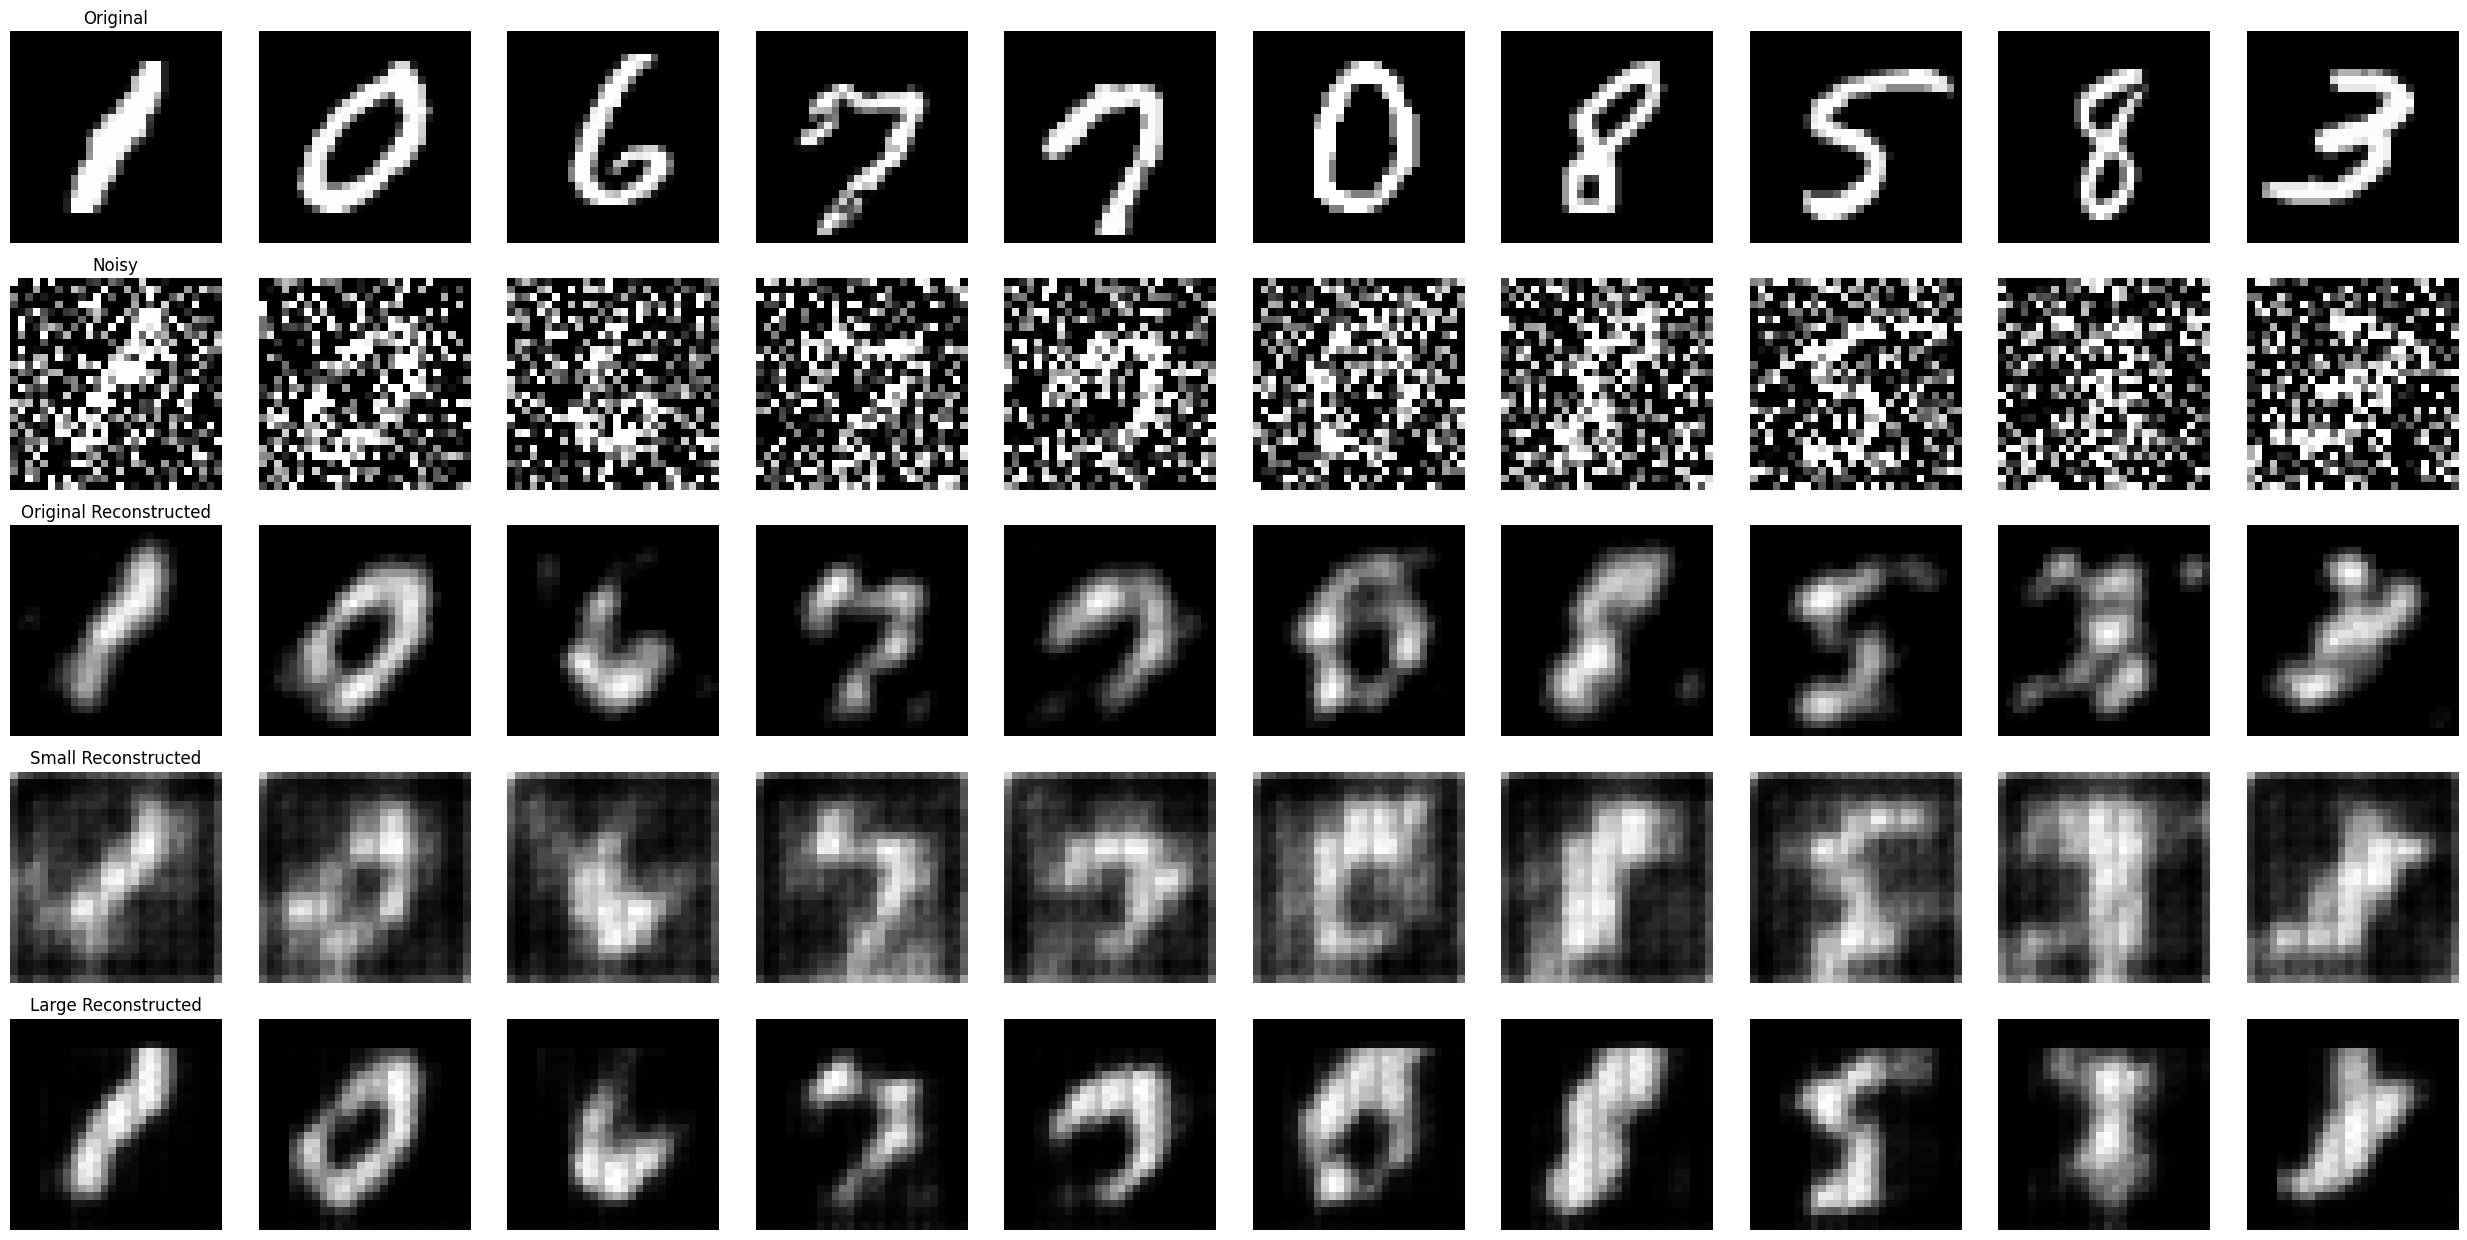

In [66]:
display_denoising_results(models, x_test_noisy, x_test, n=10)


The results look promising this timem  i will attempth to increase the batch size to obtain smoother gradients which should sharpen up the small bottleneck autoencoder. to improve the speed of the learning algoriothm i will also increade the learning rate from 0.001 to 0.03

In [72]:
# training 2 - Small Bottleneck
EPOCHS = 25
BATCH_SIZE = 1024
VALIDATION_SPLIT=0.8
LEARNING_RATE = 0.03

autoencoder_small.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='mse'
)

print("Training Small-Bottleneck AutoEncoder...")
history_small = autoencoder_small.fit(x_train_noisy, x_train,
                                      epochs=EPOCHS,
                                      batch_size=BATCH_SIZE,
                                      validation_split=VALIDATION_SPLIT,
                                      shuffle=True)



Training Small-Bottleneck AutoEncoder...
Epoch 1/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - loss: 0.0865 - val_loss: 0.0797
Epoch 2/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - loss: 0.0720 - val_loss: 0.0636
Epoch 3/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - loss: 0.0602 - val_loss: 0.0544
Epoch 4/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - loss: 0.0538 - val_loss: 0.0503
Epoch 5/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - loss: 0.0493 - val_loss: 0.0466
Epoch 6/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - loss: 0.0460 - val_loss: 0.0442
Epoch 7/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - loss: 0.0434 - val_loss: 0.0421
Epoch 8/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - loss: 0.0413 - val_loss: 0.0405
Epoch 9/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - loss: 0.0398 - val_loss: 0.0392
Epoch 10/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - loss: 0.0386 - val_loss: 0.0379
Epoch 11/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - loss: 0.0371 - val_loss: 0.0376
Epoch 12/25
12/12 ━━━━━━━━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step


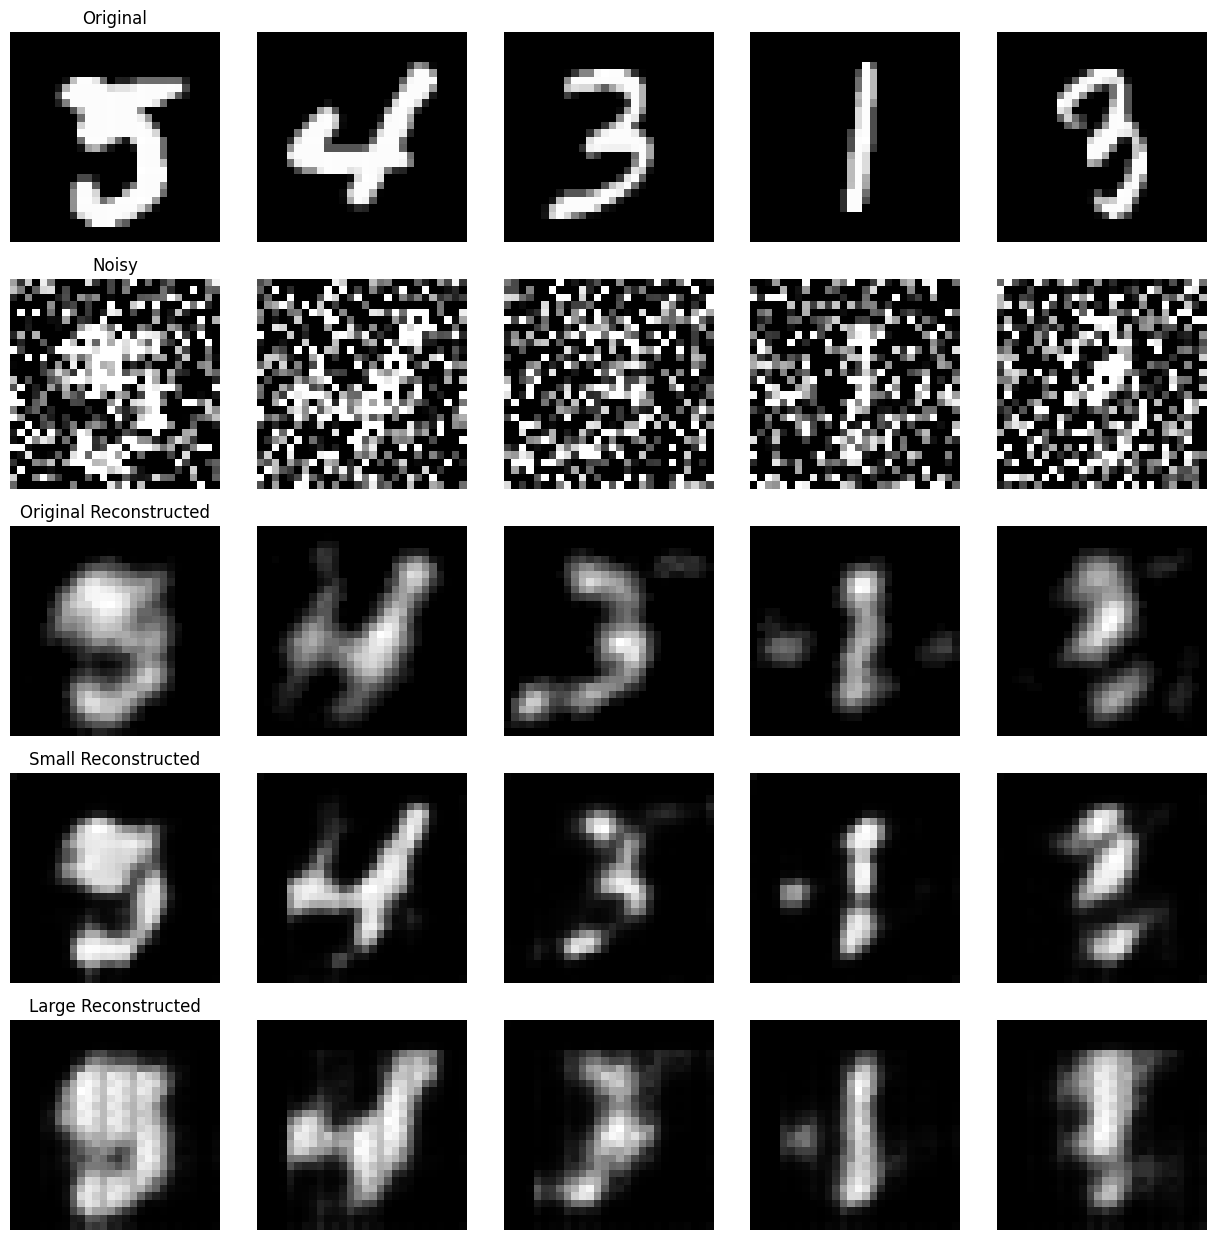

In [74]:
display_denoising_results(models, x_test_noisy, x_test, n=5)

Training large-Bottleneck AutoEncoder...
Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 32s 654ms/step - loss: 0.0439 - val_loss: 0.0420
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 46s 760ms/step - loss: 0.0410 - val_loss: 0.0395
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 42s 768ms/step - loss: 0.0384 - val_loss: 0.0369
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 40s 763ms/step - loss: 0.0362 - val_loss: 0.0354
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 34s 621ms/step - loss: 0.0345 - val_loss: 0.0342
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


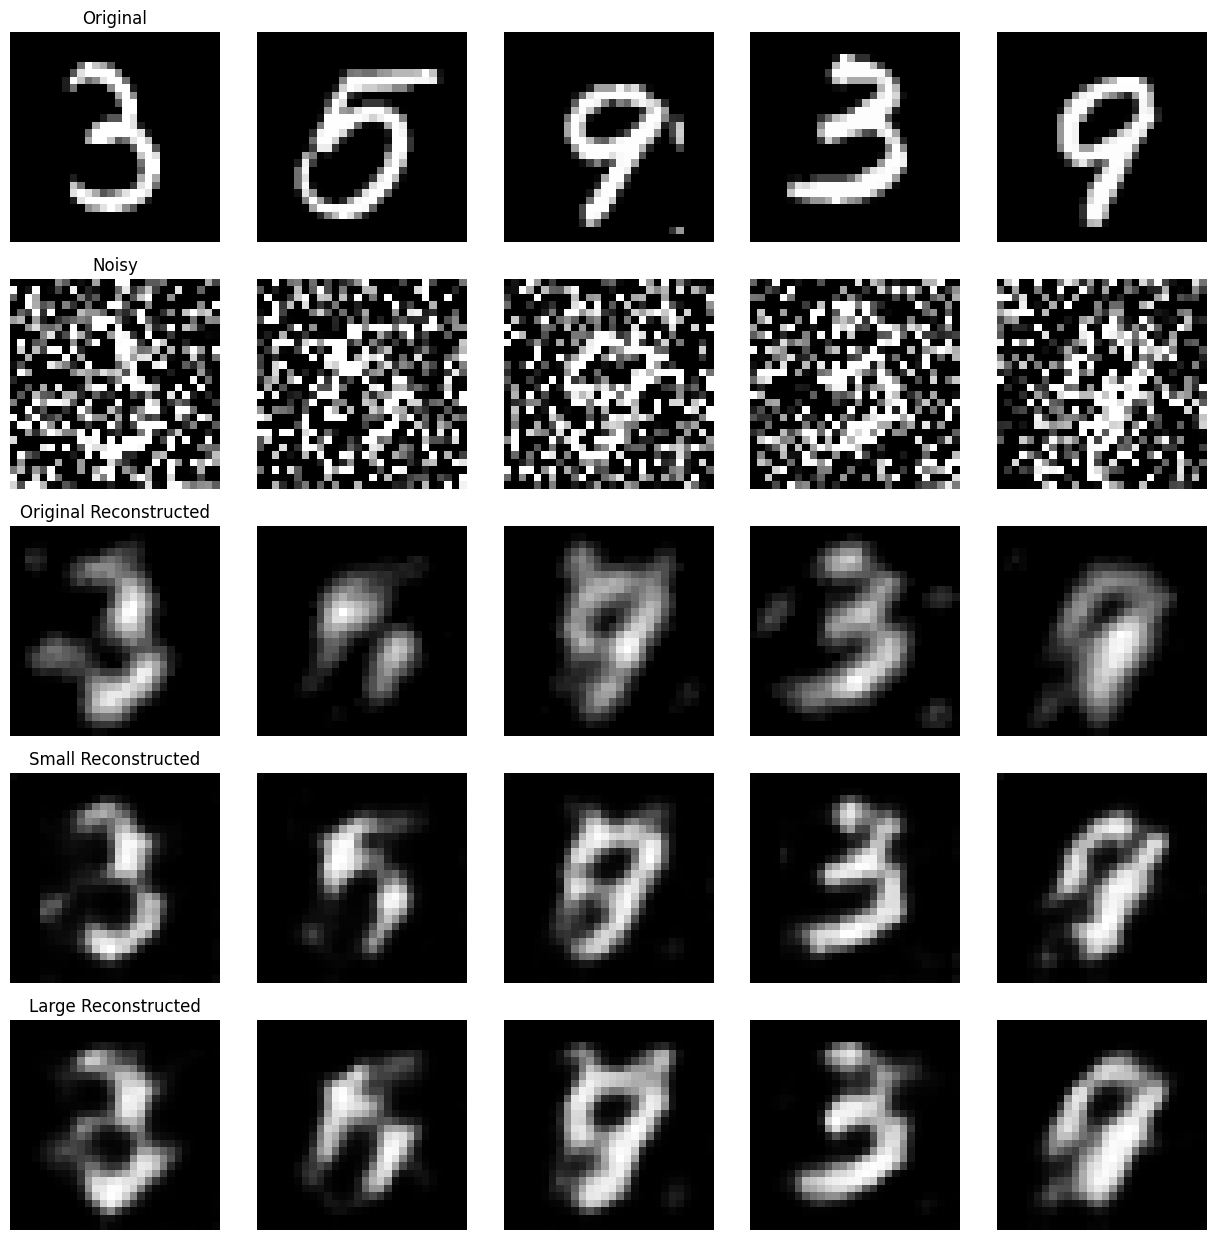

In [76]:
# training 2  - Large Bottleneck
EPOCHS = 10    # halving the epoch size to speed up the training process
BATCH_SIZE = 256 # Reducing the batch size to hopefully retain more detail and get a sharper image
VALIDATION_SPLIT=0.8
LEARNING_RATE = 0.001 # lowering the learning rate back to the default setting

autoencoder_large.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='mse'
)

print("Training large-Bottleneck AutoEncoder...")
history_large = autoencoder_large.fit(x_train_noisy, x_train,
                                      epochs=EPOCHS,
                                      batch_size=BATCH_SIZE,
                                      validation_split=VALIDATION_SPLIT,
                                      shuffle=True)

# compatring the outputs
display_denoising_results(models, x_test_noisy, x_test, n=5)

In [ ]:
### FINAL EXPLANATION

## Task 2

For the second task, you must implement a de-noising autoencoder from scratch on a more real-world dataset.

In [77]:
!wget https://github.com/gmprovan/CS6421-Assignment1/raw/master/train.zip
!wget https://github.com/gmprovan/CS6421-Assignment1/raw/master/test.zip
!wget https://github.com/gmprovan/CS6421-Assignment1/raw/master/train_cleaned.zip
!unzip train.zip
!unzip test.zip
!unzip train_cleaned.zip

--2025-03-28 03:53:52--  https://github.com/gmprovan/CS6421-Assignment1/raw/master/train.zip
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/gmprovan/CS6421-Assignment1/master/train.zip [following]
--2025-03-28 03:53:52--  https://raw.githubusercontent.com/gmprovan/CS6421-Assignment1/master/train.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19407030 (19M) [application/zip]
Saving to: ‘train.zip’

train.zip           100%[===================>]  18.51M  34.8MB/s    in 0.5s    

2025-03-28 03:53:55 (34.8 MB/s) - ‘train.zip’ saved [19407030/19407030]

--2025-03-28 03:53:55--  https://github

In [ ]:
from tensorflow.keras.preprocessing.image import load_img, array_to_img, img_to_array
import os
from sklearn.model_selection import train_test_split

X = []
Y = []

for img in os.listdir("train"):
    img = tf.keras.utils.load_img(f"train/{img}",color_mode="grayscale",target_size=(420,540))
    img = img_to_array(img).astype('float32')/255.
    X.append(img)

for img in os.listdir("train_cleaned"):
    img = load_img(f"train_cleaned/{img}",color_mode="grayscale",target_size=(420,540))
    img = img_to_array(img).astype('float32')/255.
    Y.append(img)


X = np.array(X)
Y = np.array(Y)

x_train, x_valid, y_train, y_valid = train_test_split(X, Y, test_size=0.1, random_state=111)

X = []

for img in os.listdir("test"):
    img = tf.keras.utils.load_img(f"test/{img}",color_mode="grayscale",target_size=(420,540))
    img = img_to_array(img).astype('float32')/255.
    X.append(img)

x_test = np.array(X)

This dataset consists of scans of text documents that contain noise and artificats.

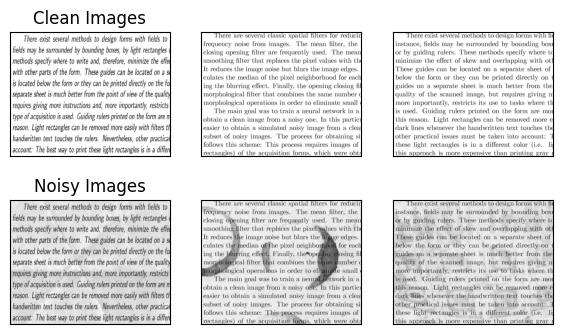

In [ ]:
n = 3
plt.figure(figsize=(7, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(y_train[i].reshape(420, 540))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
      ax.set_title('Clean Images')
for i in range(n):
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_train[i].reshape(420, 540))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title('Noisy Images')

plt.show()


## Exercise 2

1. Implement a denoising CNN autoencoder on this data, observing that the size of your images are now  (420, 540, 1). Use MSE loss. These models will take longer to train, to try to start from what you expect to be a good starting set of hyper-parametrers. Try to make the bottleneck as small as possible.
2. Visualise the results of applying this autoencoder on the train and test data for different autoencoder sizes - focusing particularly on the bottleneck size.
3. A small number of marks are available for implementing the correct regularization on this model
4. Discuss and explain the performances of differnt models and bottleneck sizes similarly to task 1.